# Thesis Evaluation Notebook

Loads `.pkl` result files and produces all thesis plots.

**Only configure Cell 2** — change `RESULTS_DIR`, `MAX_CALLS`, `VARIANTS`, `DIMENSIONS` there.

In [1]:
import os, sys, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.evaluate import postprocessing_interpolation_rewards, f_max_new

In [2]:
# ── CONFIGURE HERE ────────────────────────────────────────────────────────────
RESULTS_DIR = '../experiments/thesis_experiments/results_quick'
# RESULTS_DIR = '../experiments/thesis_experiments/results'  # full experiment

FIGURES_DIR = '../experiments/thesis_experiments/figures_quick'
# FIGURES_DIR = '../experiments/thesis_experiments/figures'  # full experiment

MAX_CALLS = 10    # 10 for quick, 300 for full

VARIANTS = [
    ('gibo_baseline_quick',   'GIBO Baseline'),
    ('gibo_prob_wolfe_quick', 'Prob Wolfe'),
    ('gibo_det_ei_quick',     'Det EI'),
]
# For full experiment:
# VARIANTS = [
#     ('gibo_baseline',   'GIBO Baseline'),
#     ('gibo_prob_wolfe', 'Prob Wolfe'),
#     ('gibo_det_ei',     'Det EI'),
# ]

DIMENSIONS = [4, 8, 12, 16, 20, 24, 28, 32, 36]

# Create figures directory
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: ../experiments/thesis_experiments/figures_quick


## Block 1: Load pkl Files

In [3]:
def load_variant(results_dir, name, dimensions):
    data = {k: {} for k in [
        'calls', 'best_so_far', 'f_max',
        'inner_loop_samples', 'step_sizes', 'gradient_norms',
        'p_wolfe_values', 'wolfe_satisfied', 'armijo_ok', 'curvature_ok',
    ]}
    for dim in dimensions:
        dim_dir = os.path.join(results_dir, name, f'dim_{dim}')
        if not os.path.isdir(dim_dir):
            continue
        pkl_files = sorted(f for f in os.listdir(dim_dir) if f.endswith('.pkl'))
        if not pkl_files:
            continue
        calls_d, bsf_d, fmax_d = [], [], []
        ils_d, ss_d, gn_d = [], [], []
        pw_d, ws_d, arm_d, cur_d = [], [], [], []
        for fname in pkl_files:
            with open(os.path.join(dim_dir, fname), 'rb') as fh:
                r = pickle.load(fh)
            fmv    = float(r['f_max'])
            regret = r['regret_per_eval']
            calls  = r['calls_at_iteration']
            bsf    = [fmv - rg for rg in regret]
            calls_d.append(calls)
            bsf_d.append([0.0] + bsf)
            fmax_d.append(fmv)
            ils_d.append(r.get('inner_loop_samples', []))
            ss_d.append(r.get('step_sizes', []))
            gn_d.append(r.get('gradient_norms', []))
            pw_d.append(r.get('p_wolfe_values', []))
            ws_d.append(r.get('wolfe_satisfied', []))
            arm_d.append(r.get('armijo_ok', []))
            cur_d.append(r.get('curvature_ok', []))
        data['calls'][dim]              = calls_d
        data['best_so_far'][dim]        = bsf_d
        data['f_max'][dim]              = fmax_d
        data['inner_loop_samples'][dim] = ils_d
        data['step_sizes'][dim]         = ss_d
        data['gradient_norms'][dim]     = gn_d
        data['p_wolfe_values'][dim]     = pw_d
        data['wolfe_satisfied'][dim]    = ws_d
        data['armijo_ok'][dim]          = arm_d
        data['curvature_ok'][dim]       = cur_d
        print(f'  dim={dim}: {len(pkl_files)} runs')
    return data


all_data = {}
for vname, vlabel in VARIANTS:
    print(f'Loading {vlabel} ({vname}) ...')
    all_data[vname] = load_variant(RESULTS_DIR, vname, DIMENSIONS)

available_dims = [
    d for d in DIMENSIONS
    if all(d in all_data[vn]['calls'] for vn, _ in VARIANTS)
]
print(f'\nAvailable dims: {available_dims}')

Loading GIBO Baseline (gibo_baseline_quick) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs
  dim=24: 11 runs
Loading Prob Wolfe (gibo_prob_wolfe_quick) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs
Loading Det EI (gibo_det_ei_quick) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs

Available dims: [4, 8, 12, 16, 20]


## Block 2: Interpolate to Common Call Grid

In [4]:
def interpolate_rewards(rewards_dict, calls_dict, max_calls):
    """
    Robust replacement for postprocessing_interpolation_rewards.
    Handles cases where last call < max_calls - 1 (avoids IndexError).

    rewards_dict : {dim: [[r0, r1, ...], ...]}  len(rewards) = len(calls) + 1
    calls_dict   : {dim: [[c0, c1, ...], ...]}
    Returns      : Tensor (n_dims, n_runs, max_calls)
    """
    dimensions = list(rewards_dict.keys())
    n_runs = len(rewards_dict[dimensions[0]])
    out = torch.zeros(len(dimensions), n_runs, max_calls)
    for idx_d, dim in enumerate(dimensions):
        for idx_r in range(n_runs):
            rewards = rewards_dict[dim][idx_r]
            calls   = calls_dict[dim][idx_r]
            ir = 0
            for call in range(max_calls):
                if ir < len(calls) and call == calls[ir]:
                    ir += 1
                out[idx_d, idx_r, call] = rewards[ir]
    return out


interpolated = {}
for vname, vlabel in VARIANTS:
    d = all_data[vname]
    rewards_dict = {dim: d['best_so_far'][dim] for dim in available_dims}
    calls_dict   = {dim: d['calls'][dim]       for dim in available_dims}
    interpolated[vname] = interpolate_rewards(rewards_dict, calls_dict, MAX_CALLS)
    print(f'{vlabel}: {interpolated[vname].shape}')

first_vname     = VARIANTS[0][0]
f_max_dict      = {dim: all_data[first_vname]['f_max'][dim] for dim in available_dims}
f_max_corrected = f_max_new(f_max_dict, list(interpolated.values()))

names   = [label for _, label in VARIANTS]
tensors = [interpolated[vname] for vname, _ in VARIANTS]

GIBO Baseline: torch.Size([5, 40, 10])
Prob Wolfe: torch.Size([5, 40, 10])
Det EI: torch.Size([5, 40, 10])


## Block 3: Regret vs Evaluations

Saved: ../experiments/thesis_experiments/figures_quick\regret_vs_evals.pdf


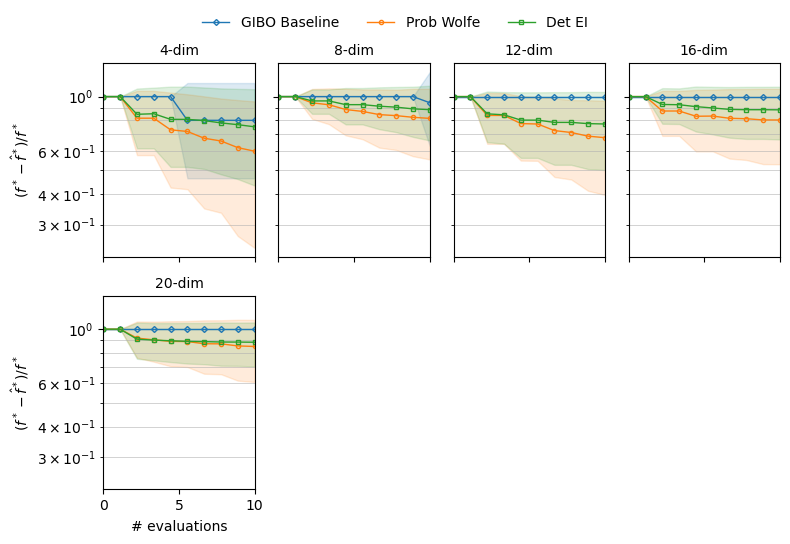

In [5]:
def plot_regret(f_max, rewards_list, names, available_dims, max_calls, show_std=True, path=None):
    markers = ['D', 'o', 's']
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
    n      = len(available_dims)
    n_cols = min(4, n)
    n_rows = int(np.ceil(n / n_cols))
    x = np.linspace(0, max_calls, max_calls)

    fig, axs = plt.subplots(n_rows, n_cols, sharex=True, sharey=True,
                             figsize=(8, 2.6 * n_rows))
    axs = np.array(axs).reshape(-1)

    for idx_d, dim in enumerate(available_dims):
        ax  = axs[idx_d]
        fmx = np.array(f_max[dim]).reshape(-1, 1)
        ax.set_title(f'{dim}-dim', fontsize=10)
        ax.set_xlim([0, max_calls])
        if idx_d >= n_cols * (n_rows - 1):
            ax.set_xlabel('# evaluations', labelpad=5)
        if idx_d % n_cols == 0:
            ax.set_ylabel(r'$(f^* - \hat{f}^*) / f^*$')
        for idx_o, (rew, name) in enumerate(zip(rewards_list, names)):
            rew_np = rew[idx_d].numpy()
            err    = (fmx - rew_np) / fmx
            err    = np.clip(err, 1e-6, None)
            mean   = err.mean(0)
            std    = err.std(0)
            ax.plot(x, mean, label=name, marker=markers[idx_o],
                    markevery=max(1, max_calls // 10), markersize=3,
                    linewidth=1., color=colors[idx_o], fillstyle='none')
            if show_std:
                ax.fill_between(x, np.clip(mean - std, 1e-6, None),
                                mean + std, alpha=0.15, color=colors[idx_o])
        ax.yaxis.grid(True, which='minor', linewidth=0.4)

    for idx_d in range(len(available_dims)):
        axs[idx_d].set_yscale('log')
    for idx in range(len(available_dims), n_rows * n_cols):
        axs[idx].set_visible(False)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 1.05), ncol=len(names), frameon=False)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_regret(f_max_corrected, tensors, names, available_dims, MAX_CALLS, show_std=True,
            path=os.path.join(FIGURES_DIR, 'regret_vs_evals.pdf'))

## Block 4: Final Regret Boxplots over Dimensions

Saved: ../experiments/thesis_experiments/figures_quick\boxplots_final_regret.pdf


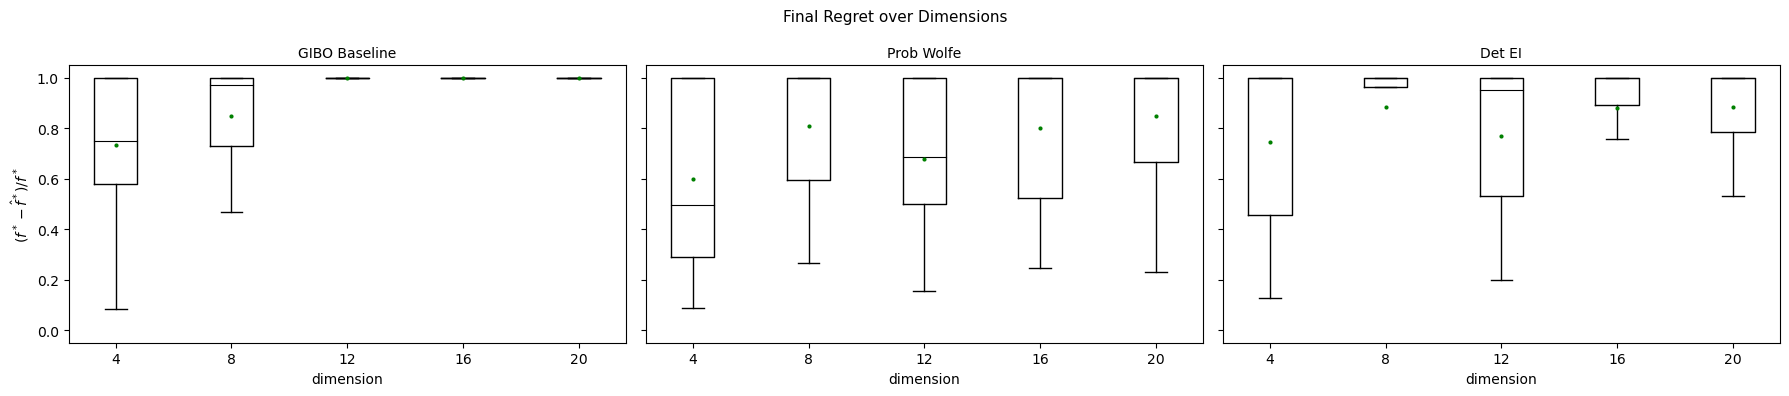

In [6]:
def plot_boxplots(f_max, rewards_list, names, available_dims, path=None):
    n_opt  = len(rewards_list)
    n_dims = len(available_dims)
    width  = max(10, n_dims * 1.2 * n_opt)
    fig, axs = plt.subplots(1, n_opt, sharex=True, sharey=True, figsize=(width, 4))
    if n_opt == 1:
        axs = [axs]
    medp  = dict(linestyle='-', linewidth=0.8, color='black')
    meanp = dict(marker='o', markerfacecolor='green', markersize=3, markeredgecolor='none')
    for idx, (rew, name) in enumerate(zip(rewards_list, names)):
        fve = []
        for idx_d, dim in enumerate(available_dims):
            fmx  = torch.tensor(f_max[dim])
            maxr = rew[idx_d].max(-1).values
            fve.append(((fmx - maxr) / fmx).numpy())
        axs[idx].boxplot(fve, positions=available_dims, widths=1.5,
                         showfliers=False, showmeans=True,
                         meanprops=meanp, medianprops=medp)
        axs[idx].set_ylim([-0.05, 1.05])
        axs[idx].set_xlabel('dimension')
        axs[idx].set_title(name, fontsize=10)
        axs[idx].set_xticks(available_dims)
    axs[0].set_ylabel(r'$(f^* - \hat{f}^*) / f^*$')
    plt.suptitle('Final Regret over Dimensions', fontsize=11)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_boxplots(f_max_corrected, tensors, names, available_dims,
              path=os.path.join(FIGURES_DIR, 'boxplots_final_regret.pdf'))

## Block 5: RQ1 — Inner Loop Sample Counts

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_samples.pdf


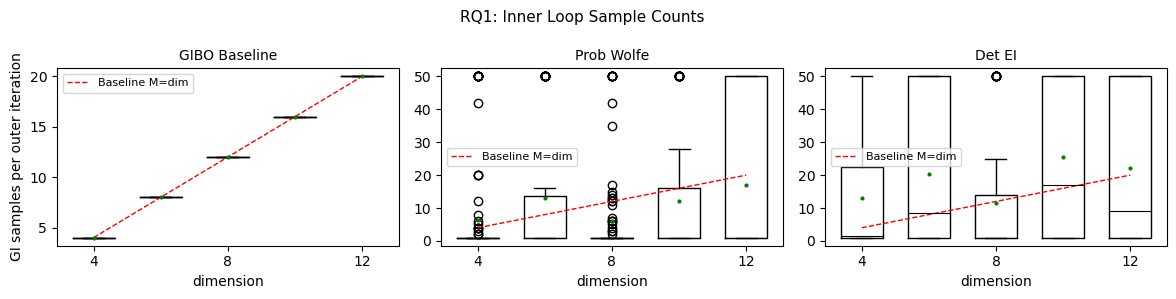

  Dim   GIBO Baseline      Prob Wolfe          Det EI
-------------------------------------------------------
    4            4.00            6.25           13.19  
    8            8.00           13.19           20.44  
   12           12.00            6.18           11.53  
   16           16.00           12.15           25.56  
   20           20.00           16.95           22.09  


In [7]:
def plot_inner_samples(all_data, variants, available_dims, path=None):
    n = len(variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=False, figsize=(4 * n, 3))
    if n == 1:
        axs = [axs]
    medp  = dict(linestyle='-', linewidth=0.8, color='black')
    meanp = dict(marker='o', markerfacecolor='green', markersize=3, markeredgecolor='none')
    for idx, (vname, vlabel) in enumerate(variants):
        data_per_dim = []
        for dim in available_dims:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            data_per_dim.append(vals if vals else [0])
        axs[idx].boxplot(data_per_dim, positions=available_dims, widths=2.5,
                         showfliers=True, showmeans=True,
                         meanprops=meanp, medianprops=medp)
        axs[idx].plot(available_dims, available_dims, 'r--', lw=1, label='Baseline M=dim')
        axs[idx].set_title(vlabel, fontsize=10)
        axs[idx].set_xlabel('dimension')
        axs[idx].set_xticks(available_dims[::2])
        axs[idx].legend(fontsize=8)
    axs[0].set_ylabel('GI samples per outer iteration')
    plt.suptitle('RQ1: Inner Loop Sample Counts', fontsize=11)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()
    print(f"{'Dim':>5}  " + '  '.join(f'{lb:>14}' for _, lb in variants))
    print('-' * (7 + 16 * len(variants)))
    for dim in available_dims:
        row = f'{dim:>5}  '
        for vname, _ in variants:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            row += f'{np.mean(vals) if vals else float("nan"):>14.2f}  '
        print(row)


plot_inner_samples(all_data, VARIANTS, available_dims,
                   path=os.path.join(FIGURES_DIR, 'inner_loop_samples.pdf'))

## Block 6: RQ2 — Step Size Distribution

Saved: ../experiments/thesis_experiments/figures_quick\step_sizes.pdf


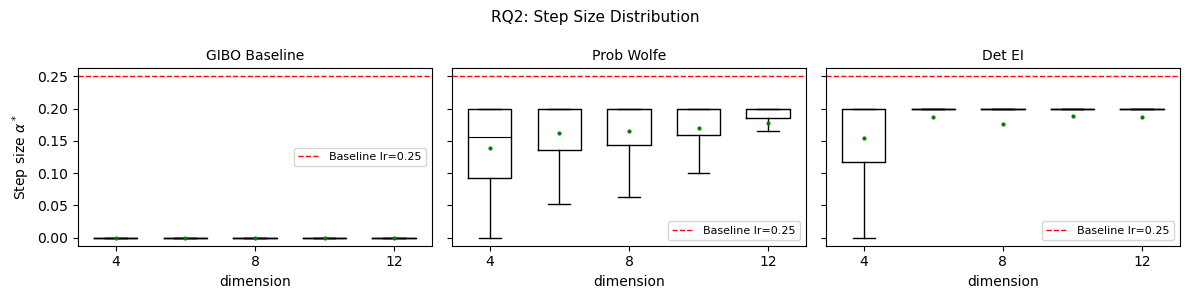

In [8]:
def plot_step_sizes(all_data, variants, available_dims, path=None):
    n = len(variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=True, figsize=(4 * n, 3))
    if n == 1:
        axs = [axs]
    medp  = dict(linestyle='-', linewidth=0.8, color='black')
    meanp = dict(marker='o', markerfacecolor='green', markersize=3, markeredgecolor='none')
    for idx, (vname, vlabel) in enumerate(variants):
        data_per_dim = []
        for dim in available_dims:
            vals = []
            for run in all_data[vname]['step_sizes'].get(dim, []):
                vals.extend([a for a in run if a is not None])
            data_per_dim.append(vals if vals else [0])
        axs[idx].boxplot(data_per_dim, positions=available_dims, widths=2.5,
                         showfliers=False, showmeans=True,
                         meanprops=meanp, medianprops=medp)
        axs[idx].axhline(0.25, color='r', linestyle='--', lw=1, label='Baseline lr=0.25')
        axs[idx].set_title(vlabel, fontsize=10)
        axs[idx].set_xlabel('dimension')
        axs[idx].set_xticks(available_dims[::2])
        axs[idx].legend(fontsize=8)
    axs[0].set_ylabel(r'Step size $\alpha^*$')
    plt.suptitle('RQ2: Step Size Distribution', fontsize=11)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_step_sizes(all_data, VARIANTS, available_dims,
                path=os.path.join(FIGURES_DIR, 'step_sizes.pdf'))

## Block 7: RQ4 — Inner Loop Length over Iterations (Early vs Late)

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_over_iters_dim4.pdf


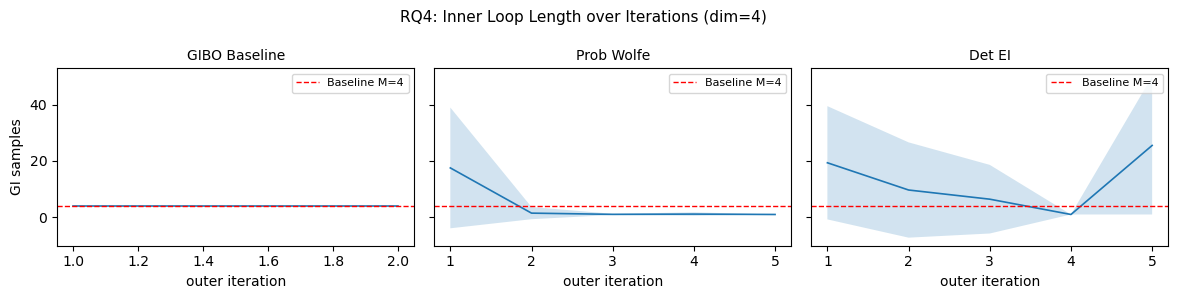

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_over_iters_dim8.pdf


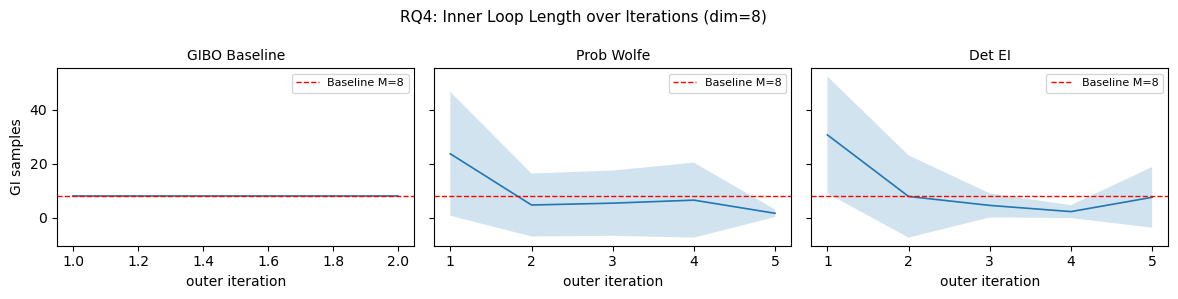

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_over_iters_dim12.pdf


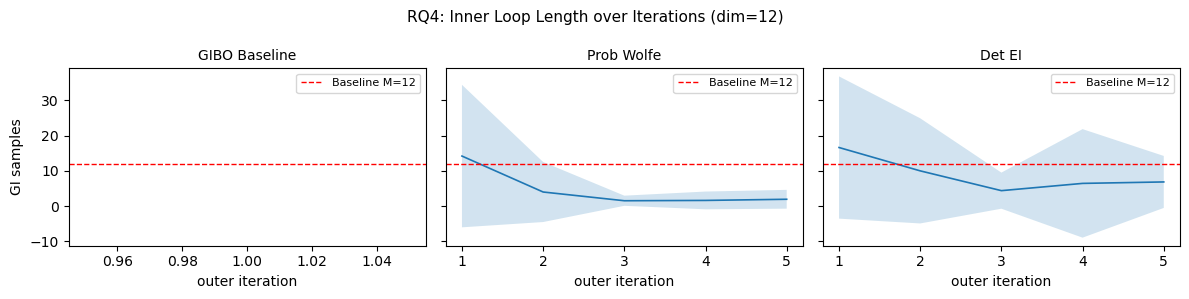

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_over_iters_dim16.pdf


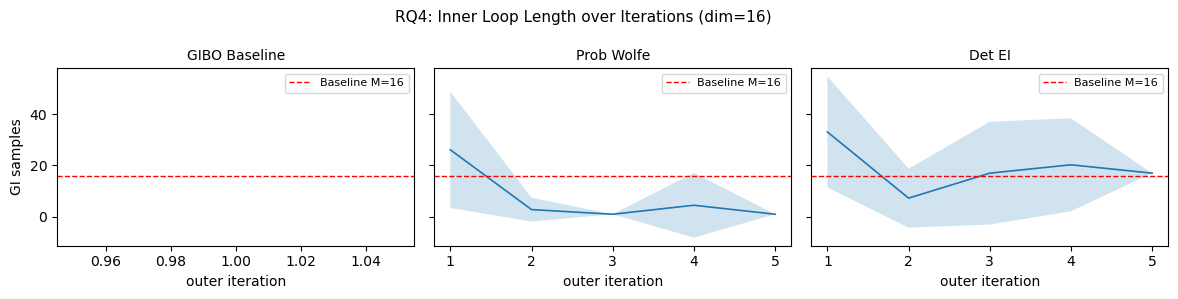

Saved: ../experiments/thesis_experiments/figures_quick\inner_loop_over_iters_dim20.pdf


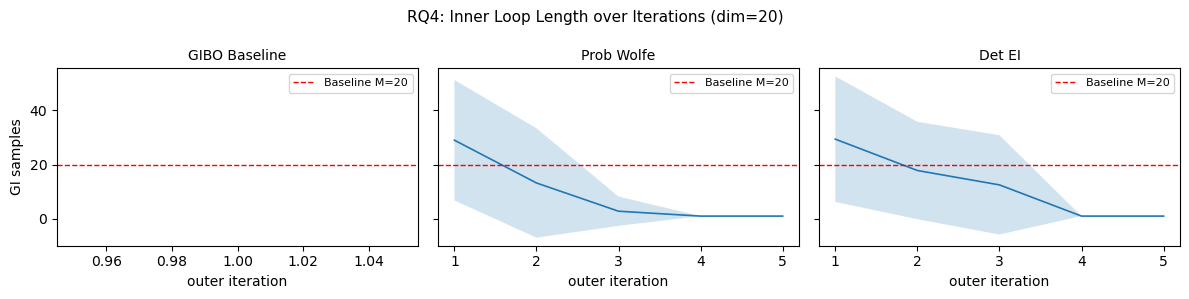

In [9]:
def plot_samples_over_iters(all_data, variants, available_dims, figures_dir=None):
    for dim in available_dims:
        n = len(variants)
        fig, axs = plt.subplots(1, n, sharey=True, figsize=(4 * n, 3))
        if n == 1:
            axs = [axs]
        for idx, (vname, vlabel) in enumerate(variants):
            runs = all_data[vname]['inner_loop_samples'].get(dim, [])
            if not runs:
                axs[idx].set_title(f'{vlabel}\n(no data)')
                continue
            max_iters = max(len(r) for r in runs)
            padded = np.full((len(runs), max_iters), np.nan)
            for i, r in enumerate(runs):
                vals = [v for v in r if v is not None]
                padded[i, :len(vals)] = vals
            mean = np.nanmean(padded, axis=0)
            std  = np.nanstd(padded, axis=0)
            x    = np.arange(1, max_iters + 1)
            axs[idx].plot(x, mean, lw=1.2)
            axs[idx].fill_between(x, mean - std, mean + std, alpha=0.2)
            axs[idx].axhline(dim, color='r', linestyle='--', lw=1, label=f'Baseline M={dim}')
            axs[idx].set_title(vlabel, fontsize=10)
            axs[idx].set_xlabel('outer iteration')
            axs[idx].legend(fontsize=8)
        axs[0].set_ylabel('GI samples')
        plt.suptitle(f'RQ4: Inner Loop Length over Iterations (dim={dim})', fontsize=11)
        plt.tight_layout()
        if figures_dir:
            path = os.path.join(figures_dir, f'inner_loop_over_iters_dim{dim}.pdf')
            plt.savefig(path, bbox_inches='tight')
            print(f'Saved: {path}')
        plt.show()


plot_samples_over_iters(all_data, VARIANTS, available_dims, figures_dir=FIGURES_DIR)

## Block 8: RQ4 — p_Wolfe Trace (Variant A)

Saved: ../experiments/thesis_experiments/figures_quick\p_wolfe_trace_dim4.pdf


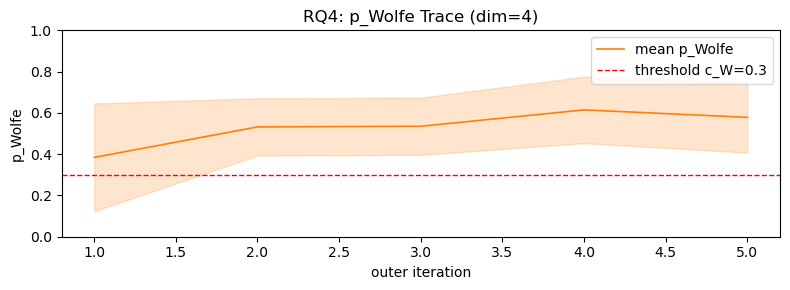

Saved: ../experiments/thesis_experiments/figures_quick\p_wolfe_trace_dim8.pdf


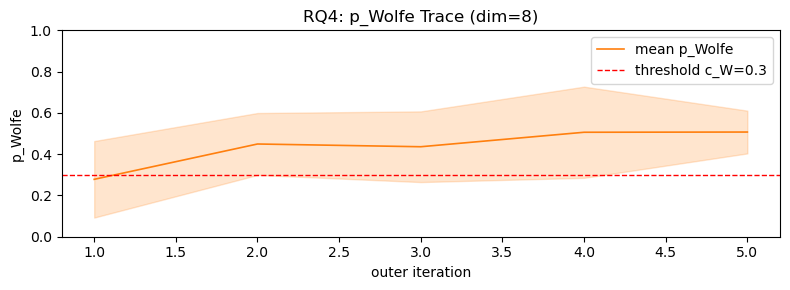

Saved: ../experiments/thesis_experiments/figures_quick\p_wolfe_trace_dim12.pdf


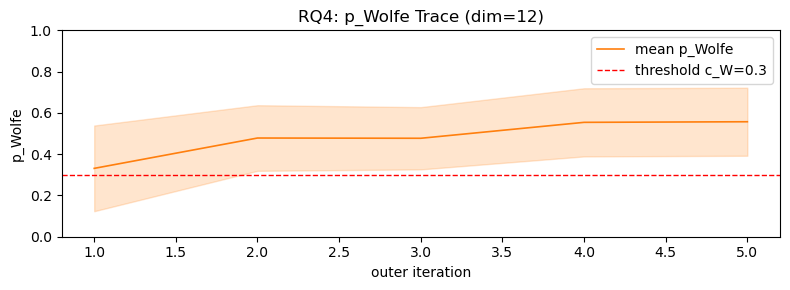

Saved: ../experiments/thesis_experiments/figures_quick\p_wolfe_trace_dim16.pdf


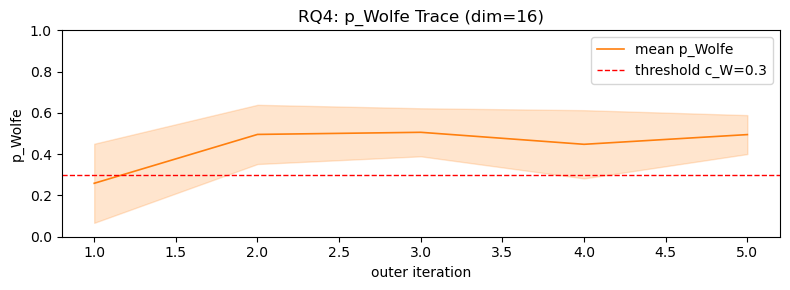

Saved: ../experiments/thesis_experiments/figures_quick\p_wolfe_trace_dim20.pdf


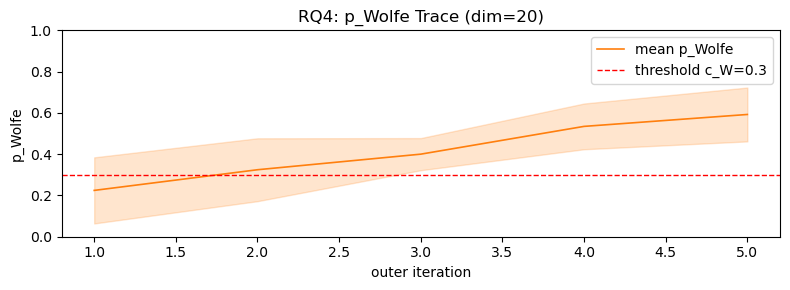

In [10]:
pw_vname = next((vn for vn, _ in VARIANTS if 'prob_wolfe' in vn), None)

if pw_vname is None:
    print('No prob_wolfe variant in VARIANTS — skipping.')
else:
    for dim in available_dims:
        runs = all_data[pw_vname]['p_wolfe_values'].get(dim, [])
        if not runs:
            print(f'No p_wolfe data for dim={dim}')
            continue
        max_iters = max(len(r) for r in runs)
        padded = np.full((len(runs), max_iters), np.nan)
        for i, r in enumerate(runs):
            vals = [v for v in r if v is not None]
            padded[i, :len(vals)] = vals
        mean = np.nanmean(padded, axis=0)
        std  = np.nanstd(padded, axis=0)
        x    = np.arange(1, max_iters + 1)
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(x, mean, lw=1.2, color='#ff7f0e', label='mean p_Wolfe')
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='#ff7f0e')
        ax.axhline(0.3, color='r', linestyle='--', lw=1, label='threshold c_W=0.3')
        ax.set_xlabel('outer iteration')
        ax.set_ylabel('p_Wolfe')
        ax.set_ylim([0, 1])
        ax.legend()
        ax.set_title(f'RQ4: p_Wolfe Trace (dim={dim})')
        plt.tight_layout()
        path = os.path.join(FIGURES_DIR, f'p_wolfe_trace_dim{dim}.pdf')
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
        plt.show()

## Block 9: RQ4 — Armijo / Curvature Satisfaction Rate (Variant B)

Saved: ../experiments/thesis_experiments/figures_quick\wolfe_satisfaction_det_ei.pdf


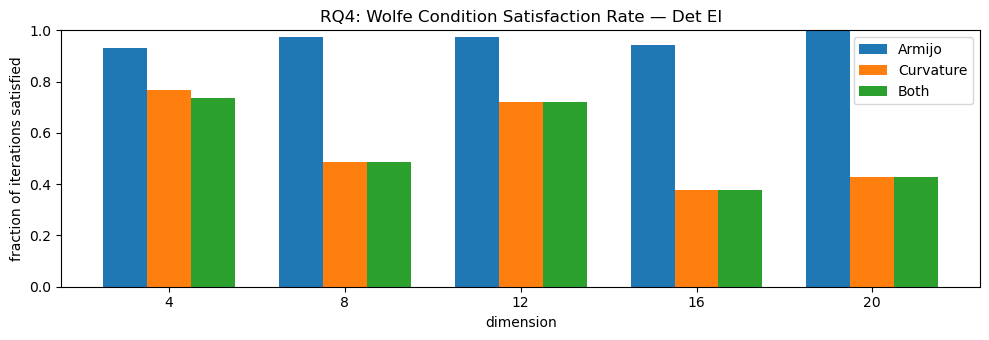

In [11]:
ei_vname = next((vn for vn, _ in VARIANTS if 'det_ei' in vn), None)

if ei_vname is None:
    print('No det_ei variant in VARIANTS — skipping.')
else:
    arm_rates, cur_rates, both_rates = [], [], []
    for dim in available_dims:
        arm_vals, cur_vals, both_vals = [], [], []
        for arm_run, cur_run in zip(
            all_data[ei_vname]['armijo_ok'].get(dim, []),
            all_data[ei_vname]['curvature_ok'].get(dim, []),
        ):
            ac = [v for v in arm_run if v is not None]
            cc = [v for v in cur_run if v is not None]
            bc = [a and c for a, c in zip(ac, cc)]
            if ac:
                arm_vals.append(np.mean(ac))
                cur_vals.append(np.mean(cc))
                both_vals.append(np.mean(bc))
        arm_rates.append(np.mean(arm_vals)   if arm_vals  else np.nan)
        cur_rates.append(np.mean(cur_vals)   if cur_vals  else np.nan)
        both_rates.append(np.mean(both_vals) if both_vals else np.nan)
    x = np.arange(len(available_dims))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(x - w, arm_rates,  width=w, label='Armijo',    color='#1f77b4')
    ax.bar(x,     cur_rates,  width=w, label='Curvature', color='#ff7f0e')
    ax.bar(x + w, both_rates, width=w, label='Both',      color='#2ca02c')
    ax.set_xticks(x)
    ax.set_xticklabels(available_dims)
    ax.set_xlabel('dimension')
    ax.set_ylabel('fraction of iterations satisfied')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.set_title('RQ4: Wolfe Condition Satisfaction Rate — Det EI')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'wolfe_satisfaction_det_ei.pdf')
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()